# Baseline 1D CNN for ECG Arrhythmia Classification

**B.Tech Project:** Explainable Deep Learning Framework for Automated ECG Arrhythmia Detection and Classification

**What this notebook does**

1. Loads the Kaggle *ECG Heartbeat Categorization Dataset* (MIT-BIH part), from Kachuee et al., 2018.
2. Looks at the class imbalance and at one example beat per class.
3. Trains a small 1D CNN with a class-weighted loss.
4. Reports accuracy, per-class precision / recall / F1, macro-F1 and a confusion matrix on the test set.
5. Draws a Grad-CAM heatmap for one beat per class (a first look at explainability).

**Dataset facts:** 109,446 beats, 187 samples per beat, 125 Hz, 5 AAMI classes: N (0), S (1), V (2), F (3), Q (4).

**Known limitation:** the train/test split of this dataset is by beat, not by patient, so beats of the same patient can be in both sets. The scores here are therefore intra-patient scores and will be higher than on unseen patients. The inter-patient (DS1/DS2) evaluation on raw MIT-BIH is the next phase of the project.

## 1. Setup

In [4]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, accuracy_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']          # label 0, 1, 2, 3, 4
CLASS_FULL = {'N': 'Normal', 'S': 'Supraventricular ectopic', 'V': 'Ventricular ectopic',
              'F': 'Fusion', 'Q': 'Unknown / paced'}
FS = 125            # sampling frequency in Hz
EPOCHS = 30
BATCH_SIZE = 128

FIG_DIR = 'figures'  # every plot is also saved here as a PNG for the slides
os.makedirs(FIG_DIR, exist_ok=True)
def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=200, bbox_inches='tight')


## 2. Load the data
Each row is one heartbeat: 187 amplitude values (scaled 0 to 1, zero-padded at the end) followed by the class label in the last column.

In [5]:
def find_data_dir():
    # looks for mitbih_train.csv anywhere under /kaggle/input (or a folder you set yourself)
    for root in [os.environ.get('ECG_DATA_DIR', ''), '/kaggle/input', '.']:
        if root and os.path.isdir(root):
            for dirname, _, filenames in os.walk(root):
                if 'mitbih_train.csv' in filenames:
                    return dirname
    raise FileNotFoundError('mitbih_train.csv not found. Add the "ECG Heartbeat Categorization Dataset" to the notebook.')

DATA_DIR = find_data_dir()
train_df = pd.read_csv(os.path.join(DATA_DIR, 'mitbih_train.csv'), header=None)
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'mitbih_test.csv'),  header=None)

X_full = train_df.iloc[:, :-1].values.astype('float32')
y_full = train_df.iloc[:, -1].values.astype('int64')
X_test = test_df.iloc[:, :-1].values.astype('float32')
y_test = test_df.iloc[:, -1].values.astype('int64')

N_SAMPLES = X_full.shape[1]
print('Data folder :', DATA_DIR)
print('Train file  :', X_full.shape, '| Test file:', X_test.shape)
print('Samples per beat:', N_SAMPLES, '=', round(N_SAMPLES / FS, 2), 's at', FS, 'Hz')

Data folder : /kaggle/input/heartbeat
Train file  : (87554, 187) | Test file: (21892, 187)
Samples per beat: 187 = 1.5 s at 125 Hz


## 3. Class imbalance
Normal beats are the large majority. This is why accuracy alone is misleading: a model that always says "N" would already score above 80%.

Class  Train beats  Train %  Test beats  Test %
    N        72471    82.77       18118   82.76
    S         2223     2.54         556    2.54
    V         5788     6.61        1448    6.61
    F          641     0.73         162    0.74
    Q         6431     7.35        1608    7.35


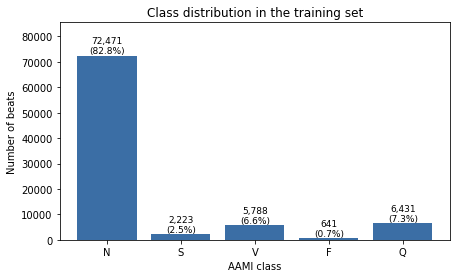

In [6]:
train_counts = np.bincount(y_full, minlength=5)
test_counts  = np.bincount(y_test, minlength=5)
dist = pd.DataFrame({'Class': CLASS_NAMES,
                     'Train beats': train_counts,
                     'Train %': (100 * train_counts / train_counts.sum()).round(2),
                     'Test beats': test_counts,
                     'Test %': (100 * test_counts / test_counts.sum()).round(2)})
print(dist.to_string(index=False))

plt.figure(figsize=(7, 4))
bars = plt.bar(CLASS_NAMES, train_counts, color='#3b6ea5')
for b, n in zip(bars, train_counts):
    plt.text(b.get_x() + b.get_width() / 2, n, f'{n:,}\n({100 * n / train_counts.sum():.1f}%)',
             ha='center', va='bottom', fontsize=9)
plt.ylim(0, train_counts.max() * 1.18)
plt.xlabel('AAMI class'); plt.ylabel('Number of beats')
plt.title('Class distribution in the training set')
savefig('01_class_distribution.png'); plt.show()

## 4. One example beat per class

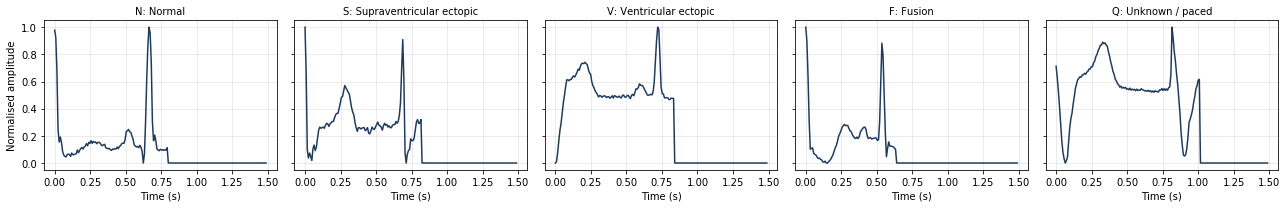

In [7]:
t = np.arange(N_SAMPLES) / FS
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
for k, ax in enumerate(axes):
    idx = np.where(y_full == k)[0][0]
    ax.plot(t, X_full[idx], color='#1f3b5c', linewidth=1.5)
    ax.set_title(f'{CLASS_NAMES[k]}: {CLASS_FULL[CLASS_NAMES[k]]}', fontsize=10)
    ax.set_xlabel('Time (s)'); ax.grid(alpha=0.3)
axes[0].set_ylabel('Normalised amplitude')
plt.tight_layout(); savefig('02_example_beats.png'); plt.show()

## 5. Train / validation split and class weights
- 20% of the training file is held out as a **validation set** (stratified, so every class keeps its share). It is used for early stopping.
- The **test file is never used during training**. It is touched only once, at the end.
- Instead of copying rare beats many times (upsampling), the loss gives each class a weight `w_c = N / (K * n_c)`, so a mistake on a rare class costs more.

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=SEED)

# Conv1D expects shape (beats, samples, channels)
X_train, X_val, X_test_c = X_train[..., None], X_val[..., None], X_test[..., None]

weights = compute_class_weight('balanced', classes=np.arange(5), y=y_train)
class_weight = {i: float(w) for i, w in enumerate(weights)}

print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test_c.shape)
for i, w in class_weight.items():
    print(f'  weight for class {CLASS_NAMES[i]}: {w:.2f}')

Train: (70043, 187, 1) | Val: (17511, 187, 1) | Test: (21892, 187, 1)
  weight for class N: 0.24
  weight for class S: 7.88
  weight for class V: 3.03
  weight for class F: 27.31
  weight for class Q: 2.72


## 6. The model: baseline 1D CNN
Three convolution blocks (32, 64, 128 filters), each followed by batch normalisation, ReLU and max-pooling. Global average pooling then turns the feature maps into one vector, followed by a 64-unit dense layer and a 5-way softmax.

In [9]:
def build_cnn(n_samples, n_classes=5):
    inp = keras.Input(shape=(n_samples, 1), name='beat')
    x = inp
    for i, (filters, kernel) in enumerate([(32, 7), (64, 5), (128, 3)], start=1):
        x = layers.Conv1D(filters, kernel, padding='same', name=f'conv{i}')(x)
        x = layers.BatchNormalization(name=f'bn{i}')(x)
        x = layers.Activation('relu', name=f'relu{i}')(x)
        x = layers.MaxPooling1D(2, name=f'pool{i}')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(64, activation='relu', name='dense')(x)
    x = layers.Dropout(0.3, name='dropout')(x)
    out = layers.Dense(n_classes, activation='softmax', name='class_probs')(x)
    return keras.Model(inp, out, name='baseline_1d_cnn')

model = build_cnn(N_SAMPLES)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "baseline_1d_cnn"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
beat (InputLayer)            [(None, 187, 1)]          0         
_________________________________________________________________
conv1 (Conv1D)               (None, 187, 32)           256       
_________________________________________________________________
bn1 (BatchNormalization)     (None, 187, 32)           128       
_________________________________________________________________
relu1 (Activation)           (None, 187, 32)           0         
_________________________________________________________________
pool1 (MaxPooling1D)         (None, 93, 32)            0         
_________________________________________________________________
conv2 (Conv1D)               (None, 93, 64)            10304     
_________________________________________________________________
bn2 (BatchNormalization)     (None, 93, 64)        

## 7. Training

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5),
]
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    class_weight=class_weight, callbacks=callbacks, verbose=2)
model.save('baseline_1d_cnn.keras')

Train on 70043 samples, validate on 17511 samples
Epoch 1/30
70043/70043 - 40s - loss: 0.7056 - accuracy: 0.6141 - val_loss: 1.5271 - val_accuracy: 0.1445
Epoch 2/30
70043/70043 - 38s - loss: 0.4392 - accuracy: 0.7955 - val_loss: 4.2889 - val_accuracy: 0.8200
Epoch 3/30
70043/70043 - 37s - loss: 0.3755 - accuracy: 0.8335 - val_loss: 1.6190 - val_accuracy: 0.3579
Epoch 4/30
70043/70043 - 37s - loss: 0.3430 - accuracy: 0.8490 - val_loss: 0.9108 - val_accuracy: 0.3817
Epoch 5/30
70043/70043 - 37s - loss: 0.3277 - accuracy: 0.8561 - val_loss: 0.7683 - val_accuracy: 0.8627
Epoch 6/30
70043/70043 - 38s - loss: 0.3117 - accuracy: 0.8608 - val_loss: 0.6619 - val_accuracy: 0.3970
Epoch 7/30
70043/70043 - 38s - loss: 0.2927 - accuracy: 0.8685 - val_loss: 0.3900 - val_accuracy: 0.8472
Epoch 8/30
70043/70043 - 37s - loss: 0.2873 - accuracy: 0.8716 - val_loss: 0.4885 - val_accuracy: 0.8922
Epoch 9/30
70043/70043 - 38s - loss: 0.2687 - accuracy: 0.8796 - val_loss: 0.5202 - val_accuracy: 0.9477
Epoch

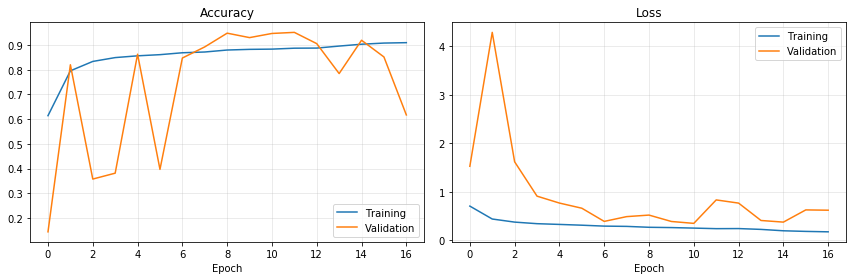

In [12]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['accuracy'], label='Training'); ax[0].plot(h['val_accuracy'], label='Validation')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(h['loss'], label='Training'); ax[1].plot(h['val_loss'], label='Validation')
ax[1].set_title('Loss'); ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); savefig('03_training_curves.png'); plt.show()

## 8. Results on the test set
Macro-F1 is the plain average of the five per-class F1 scores, so the rare classes count as much as N.

In [15]:
probs = model.predict(X_test_c, batch_size=512, verbose=0)

y_pred = probs.argmax(axis=1)

acc = accuracy_score(y_test, y_pred)

prec, rec, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=np.arange(5)
)

results = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Precision': prec,
    'Recall': rec,
    'F1': f1,
    'Test beats': support
}).round(4)

results.to_csv('baseline_results.csv', index=False)

print(f'Test accuracy : {100 * acc:.2f}%')
print(f'Macro-F1      : {100 * f1.mean():.2f}%')
print()
print(results.to_string(index=False))
print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

Test accuracy : 94.41%
Macro-F1      : 76.29%

Class  Precision  Recall      F1  Test beats
    N     0.9813  0.9594  0.9702       18118
    S     0.5586  0.6691  0.6088         556
    V     0.8713  0.8605  0.8659        1448
    F     0.2602  0.8642  0.4000         162
    Q     0.9896  0.9502  0.9695        1608

              precision    recall  f1-score   support

           N     0.9813    0.9594    0.9702     18118
           S     0.5586    0.6691    0.6088       556
           V     0.8713    0.8605    0.8659      1448
           F     0.2602    0.8642    0.4000       162
           Q     0.9896    0.9502    0.9695      1608

    accuracy                         0.9441     21892
   macro avg     0.7322    0.8607    0.7629     21892
weighted avg     0.9585    0.9441    0.9498     21892



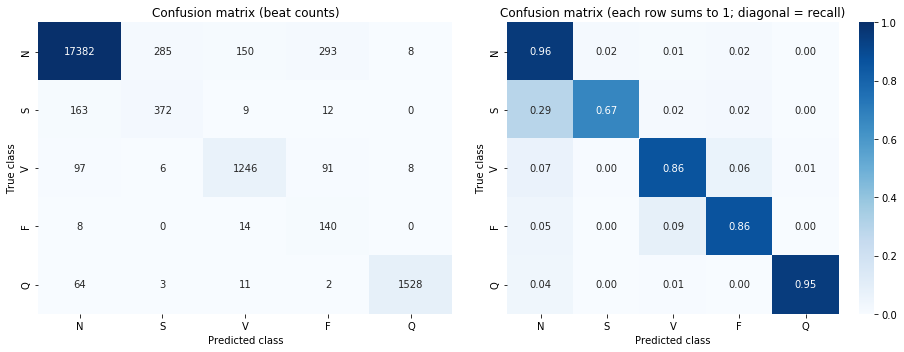

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(5))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[0])
ax[0].set_title('Confusion matrix (beat counts)')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[1])
ax[1].set_title('Confusion matrix (each row sums to 1; diagonal = recall)')
for a in ax:
    a.set_xlabel('Predicted class'); a.set_ylabel('True class')
plt.tight_layout(); savefig('04_confusion_matrix.png'); plt.show()

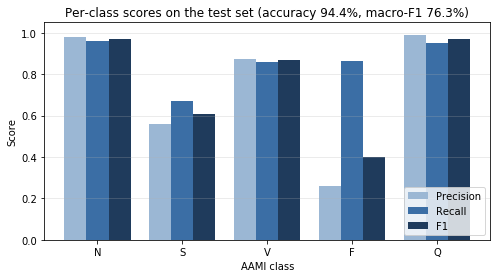

In [17]:
x = np.arange(5); w = 0.26
plt.figure(figsize=(8, 4))
plt.bar(x - w, prec, w, label='Precision', color='#9bb7d4')
plt.bar(x,     rec,  w, label='Recall',    color='#3b6ea5')
plt.bar(x + w, f1,   w, label='F1',        color='#1f3b5c')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.05); plt.ylabel('Score'); plt.xlabel('AAMI class')
plt.title(f'Per-class scores on the test set (accuracy {100 * acc:.1f}%, macro-F1 {100 * f1.mean():.1f}%)')
plt.legend(loc='lower right'); plt.grid(axis='y', alpha=0.3)
savefig('05_per_class_scores.png'); plt.show()

## 9. Grad-CAM: where does the model look?
Grad-CAM takes the feature maps of the last convolution block and weights each one by how strongly it pushes the predicted class score up. The result is one importance value per time step, stretched back to the 187 samples of the beat. Darker red = more important for the decision.

This is a qualitative preview only. Checking the heatmaps against the P / QRS / T regions with numbers is part of the next phase.

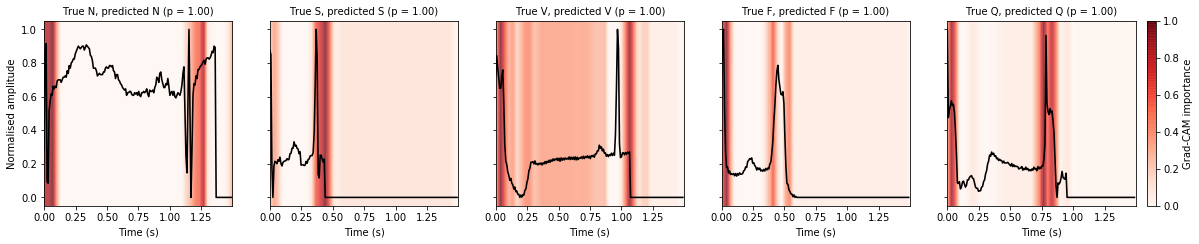

In [18]:
def grad_cam(model, beat, class_idx, layer_name='relu3'):
    # beat: array of shape (n_samples,). Returns a heatmap of the same length, scaled 0 to 1.
    grad_model = keras.Model(model.inputs, [model.get_layer(layer_name).output, model.output])
    x = tf.convert_to_tensor(beat.reshape(1, -1, 1), dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x, training=False)
        if isinstance(preds, (list, tuple)):
            preds = preds[0]
        score = preds[:, class_idx]
    grads = tape.gradient(score, conv_out)                 # (1, steps, channels)
    alpha = tf.reduce_mean(grads, axis=1, keepdims=True)   # one weight per channel
    cam = tf.nn.relu(tf.reduce_sum(alpha * conv_out, axis=-1))[0].numpy()
    if cam.max() > 0:
        cam = cam / cam.max()
    steps = np.linspace(0, len(beat) - 1, len(cam))
    return np.interp(np.arange(len(beat)), steps, cam)

im = None
fig, axes = plt.subplots(1, 5, figsize=(20, 3.4), sharey=True)
for k, ax in enumerate(axes):
    correct = np.where((y_test == k) & (y_pred == k))[0]
    if len(correct) == 0:
        ax.set_title(f'{CLASS_NAMES[k]}: no correctly classified beat'); ax.axis('off'); continue
    idx = correct[np.argmax(probs[correct, k])]            # the most confident correct beat
    beat = X_test[idx]
    cam = grad_cam(model, beat, k)
    im = ax.imshow(cam[None, :], aspect='auto', cmap='Reds', vmin=0, vmax=1, alpha=0.75,
                   extent=[0, N_SAMPLES / FS, beat.min() - 0.05, beat.max() + 0.05])
    ax.plot(t, beat, color='black', linewidth=1.6)
    ax.set_title(f'True {CLASS_NAMES[k]}, predicted {CLASS_NAMES[k]} (p = {probs[idx, k]:.2f})', fontsize=10)
    ax.set_xlabel('Time (s)')
axes[0].set_ylabel('Normalised amplitude')
if im is not None:
    fig.colorbar(im, ax=axes, fraction=0.012, pad=0.01, label='Grad-CAM importance')
savefig('06_gradcam_examples.png'); plt.show()

## 10. How this baseline differs from the planned framework

| | This baseline (now) | Planned framework (next phase) |
|---|---|---|
| Data source | Kaggle ECG Heartbeat Categorization Dataset (pre-segmented MIT-BIH beats) | Raw MIT-BIH records from PhysioNet, lead MLII |
| Sampling rate | 125 Hz (downsampled) | 360 Hz (original) |
| Beat length | 187 samples, zero-padded | 252 samples around the R peak |
| Preprocessing | Already done by the dataset authors | Our own band-pass filter, segmentation, z-score |
| Classes | 5: N, S, V, F, Q | 4: N, S, V, F (paced / Q beats removed) |
| Split | Beat-wise split given with the dataset (intra-patient) | Intra-patient and inter-patient DS1 / DS2 |
| Features | Beat shape only | Beat shape + RR intervals |
| Model | 1D CNN | 1D CNN baseline and CNN-LSTM + RR |
| Explainability | Grad-CAM example plots | Grad-CAM and SHAP, scored with region-share and deletion tests |
| Noise | Clean beats only | NSTDB muscle noise at 18 / 6 / 0 dB |

**To do**
1. Build our own preprocessing pipeline on raw MIT-BIH (filter, segment, RR features, AAMI mapping).
2. Retrain this CNN on the 252-sample, 4-class beats.
3. Evaluate with the inter-patient DS1 / DS2 split.
4. Add the CNN-LSTM + RR model and compare it with this baseline.
5. Add SHAP and the quantitative explanation metrics.
6. Run the noise robustness tests.

## 11. Summary (copy these numbers into the slide)

In [19]:
print('BASELINE 1D CNN, Kaggle ECG Heartbeat Categorization Dataset (MIT-BIH part)')
print(f'Model parameters     : {model.count_params():,}')
print(f'Epochs run           : {len(h["loss"])}')
print(f'Test beats           : {len(y_test):,}')
print(f'Test accuracy        : {100 * acc:.2f}%')
print(f'Macro-F1             : {100 * f1.mean():.2f}%')
for name, p, r, f in zip(CLASS_NAMES, prec, rec, f1):
    print(f'  {name}: precision {100 * p:5.1f}%  recall {100 * r:5.1f}%  F1 {100 * f:5.1f}%')
print()
print('Saved figures:', sorted(os.listdir(FIG_DIR)))
print('Saved files  : baseline_results.csv, baseline_1d_cnn.keras')

BASELINE 1D CNN, Kaggle ECG Heartbeat Categorization Dataset (MIT-BIH part)
Model parameters     : 44,741
Epochs run           : 17
Test beats           : 21,892
Test accuracy        : 94.41%
Macro-F1             : 76.29%
  N: precision  98.1%  recall  95.9%  F1  97.0%
  S: precision  55.9%  recall  66.9%  F1  60.9%
  V: precision  87.1%  recall  86.0%  F1  86.6%
  F: precision  26.0%  recall  86.4%  F1  40.0%
  Q: precision  99.0%  recall  95.0%  F1  97.0%

Saved figures: ['01_class_distribution.png', '02_example_beats.png', '03_training_curves.png', '04_confusion_matrix.png', '05_per_class_scores.png', '06_gradcam_examples.png']
Saved files  : baseline_results.csv, baseline_1d_cnn.keras
